In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
run = ds.pipeline.open(label="docs_default")
graph = run["connectivity_map"]
umap = run["umap"]
paris = ds.run_paris_clustering(graph, n_clusters=15)

In [2]:
paris_result = ds.load_paris_clustering(paris)
pd.Series(paris_result.labels).value_counts().sort_index()

1     658
2     611
3     410
4     385
5     337
6     303
7     257
8     255
9     243
10    202
11    137
12     88
13     27
14     15
15     12
Name: count, dtype: int64

In [3]:
sampling = ds.run_topacedo_sampler(
    graph,
    paris,
    max_sampling_rate=0.1,
)
sampling_data = ds.load_artifact(sampling)
sampled = np.asarray(sampling_data["sampled"][:], dtype=bool)
seeds = np.asarray(sampling_data["seeds"][:], dtype=bool)
density = np.asarray(sampling_data["density"][:])
mean_snn = np.asarray(sampling_data["mean_snn"][:])
{
    "cells": int(sampled.size),
    "selected": int(sampled.sum()),
    "seeds": int(seeds.sum()),
}

INFO: 359 cells (9.11%) sub-sampled. Subsample to Seed (152 cells) ratio: 2.362


Constructing graph from dendrogram: 3939 / 3939 complete

{'cells': 3940, 'selected': 359, 'seeds': 152}

In [4]:
summary = pd.DataFrame(
    {
        "cluster": paris_result.labels,
        "sampled": sampled,
        "seed": seeds,
        "density": density,
        "mean_snn": mean_snn,
    }
)
summary.groupby("cluster", sort=True).agg(
    cells=("sampled", "size"),
    selected=("sampled", "sum"),
    seeds=("seed", "sum"),
    mean_density=("density", "mean"),
    mean_snn=("mean_snn", "mean"),
)

,cells,selected,seeds,mean_density,mean_snn
cluster,,,,,
1,658,30,14,1602.027356,2.523556
2,611,31,12,1630.540669,2.748118
3,410,45,17,1372.410130,3.601220
4,385,50,19,1327.895880,3.780779
5,337,31,12,1447.008491,3.663798
6,303,28,13,1364.251242,3.525743
7,257,21,9,1461.142364,3.980545
8,255,33,15,1246.862924,4.130588
9,243,20,7,1498.047238,3.856790


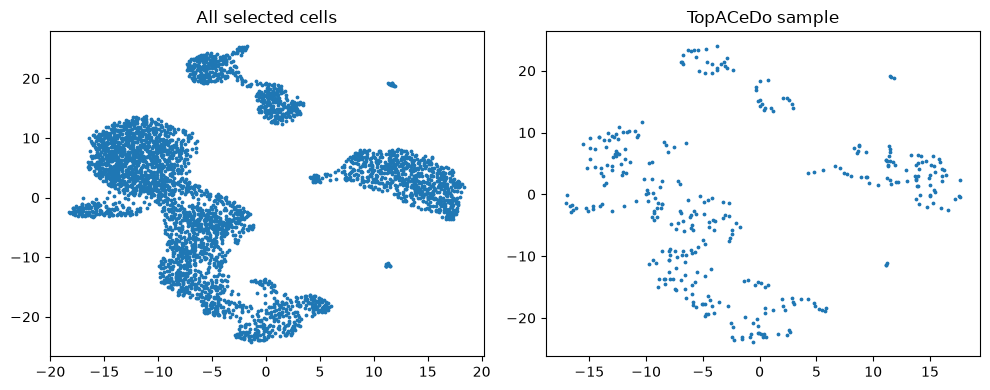

In [5]:
coordinates = np.asarray(ds.load_artifact(umap)["values"][:])
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(coordinates[:, 0], coordinates[:, 1], s=3)
axes[0].set_title("All selected cells")
axes[1].scatter(coordinates[sampled, 0], coordinates[sampled, 1], s=3)
axes[1].set_title("TopACeDo sample")
figure.tight_layout()

In [6]:
ds.cells.insert(
    "topacedo_selected",
    sampled,
    key="I",
    fill_value=False,
    overwrite=True,
)

export_directory = TemporaryDirectory()
subset_path = Path(export_directory.name) / "subset.zarr"
writer = scarf.SubsetZarr(
    zarr_loc=str(subset_path),
    assays=[ds.RNA],
    cell_key="topacedo_selected",
    reset_cell_filter=False,
    overwrite_existing_file=True,
)
writer.dump()

subset = scarf.DataStore(str(subset_path))
subset.cells.N, subset.RNA.feats.N

(359, 33538)